# MLP with hyperparameter Tuning [(medium-article)](https://medium.com/@vijaikdasari/multilayer-perceptron-and-its-hyperparameter-tuning-deedfbca2d1b)

- Grid search --> all combinations, smaller networks + limited hyperparameter ranges
- Random search --> random combinations, high-dimensional hyperparameter spaces
- Bayesian optimization --> probabilistic model that balances exploration (trying new hyperparameter combinations) and exploitation (refining around known good values), complex model + large datasets
- Automated Machine Learning (AutoML) Tools --> flexible hyperparameter search configurations, Keras Tuner / Optuna

## Import

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
from src.config import RANDOM_SEED
import src.pipeline as pipe
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import optuna
import pickle
import numpy as np
import tensorflow as tf
from optuna.samplers import TPESampler, RandomSampler
from sklearn.preprocessing import MinMaxScaler

## Setup

In [23]:
# INDICATORS = [i for i in df.columns if i != 'Year']
# per ora lo faccio solo su sti tre per capire se funziona
INDICATORS = ['Fertilizer consumption (kilograms per hectare of arable land)']
# 'Employment in agriculture (% of total employment)'
# 'Agricultural raw materials imports (% of merchandise imports)', 
# 'Cereal yield (kg per hectare)'
# 'Fertilizer consumption (% of fertilizer production)',
# 'Agriculture, forestry, and fishing, value added (% of GDP)'
# 'Rural population (% of total population)'
# 'Crop production index (2014-2016 = 100)'

DF_CATEGORIES = ["orig", "step_aug", "jitter_aug"]

## Upload

In [24]:
df = pipe.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


## Splitting + augmentation + saving
- splitting della time serie originale in train, validation e test set,
- augmentation su train set originale (prevent data leakage) con step function e linear interpolation + jitter,
- creazione di un dizionario che contiene tutte queste cose

l'orizzonte di test è adattivo in base alla disponibilità dei dati storici di ciascun indicatore. Siccome serie sono corte ho dato priorità ad avere un punto in più nel validation set piuttosto che nel test set

============================== FERTILIZER CONSUMPTION (KILOGRAMS PER HECTARE OF ARABLE LAND) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\AUGMENTATION\AUG_fertilizer_abs.png


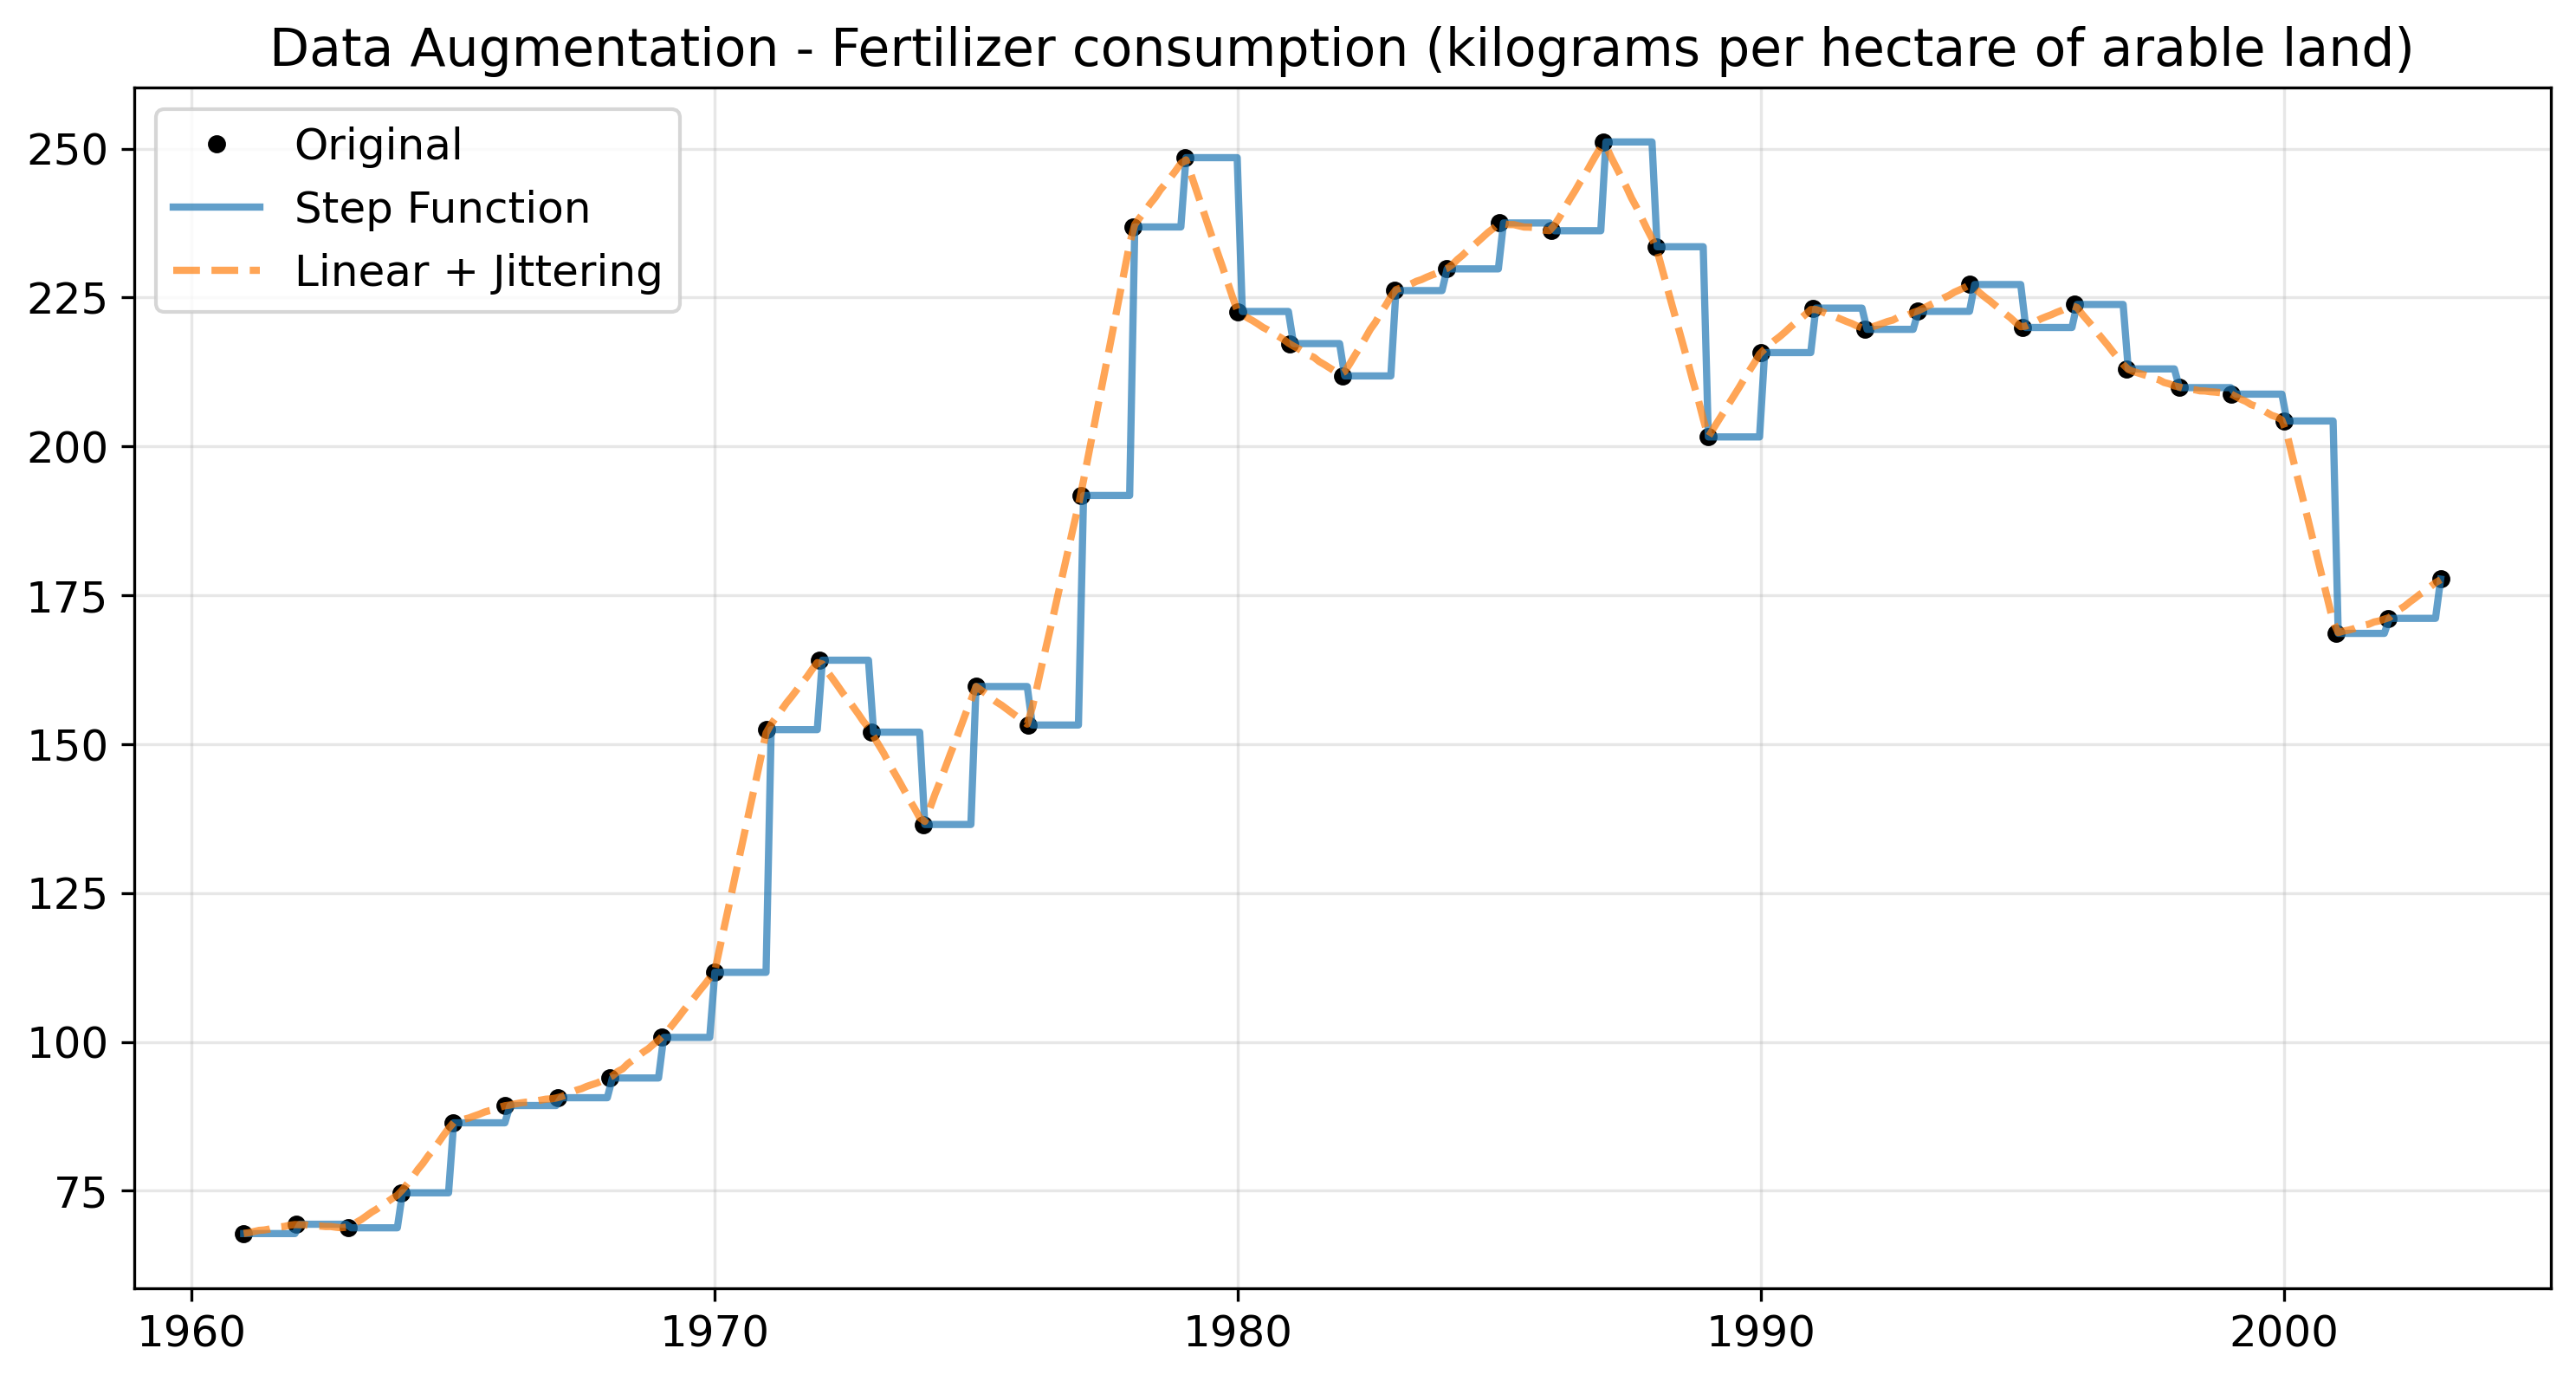

In [25]:
# dizionario per salvare in memoria i subset originali e i train aumentati con step e linear
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    # faccio augmentation SOLO sul train set: aumento sia anni che valori
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

## Scaling
- scaling di tutto ciò che è all'interno del dizionario facendo fit su valori del train originale (diviso per anno e valore) e transform sui dataframe aumentati.

In [26]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}

for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

## Definition of search space = objective function for RandomSearch and Optuna

In [27]:
def objective(trial, scaled_data_dict):
    """
    Defines an objective function that is used in hyperparameter optimization, specifically with Optuna.
    
    Args: 
        trial = which is an Optuna Trial object used to sample hyperparameters
        scaled_data_dict = contains scaled training and validation data
        
    Returns:
        best_val_loss = minimum validation loss gotten
    """
    
    params = {
        # iperparametri riguardanti la struttura della rete
        'n_layers': trial.suggest_int('n_layers', 1, 3),
        'units': trial.suggest_int('units', 8, 64),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        
        # iperparametri riguardanti traning
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [8, 16, 32]),
        'dropout': trial.suggest_categorical('dropout', [0.1, 0.2, 0.3])
    }
    
    # iperparametri riguardanti i dati
    n_input_steps = trial.suggest_categorical('n_input_steps', [3, 5, 10])
    
    train_data = scaled_data_dict['train'] 
    val_data = scaled_data_dict['val']
    
    X_train, y_train = pipe.create_sequences(train_data['Value'], n_input_steps)
    X_val, y_val = pipe.create_sequences(val_data['Value'], n_input_steps)
    
    # Check di sicurezza: se la window è troppo grande e i dati pochi, X è vuoto
    if len(X_train) == 0 or len(X_val) == 0:
        raise optuna.TrialPruned() # Abortisci questo tentativo

    model = nn.build_mlp_model(params, input_dim=n_input_steps)
    history, model = nn.train_model(    
        model, 
        X_train, y_train, 
        X_val, y_val,
        batch_size=params['batch_size'],
        epochs=50,
        patience=10
        # extra_callbacks=[prune_cb]
    )
    
    # RETURNS SCORE = lowest validation loss gotten
    if 'val_loss' not in history.history:
        return float('inf')
        
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss

In [28]:
tuning_results = []
BACKUP_FILE = "tuning_results_backup.pkl"
N_TRIALS = 7

for SAMPLER_MODE in ["Random", "TPE"]:
    for indicator in INDICATORS:
        print(f"\n{'='*40} PROCESSING: {indicator} [{SAMPLER_MODE}] {'='*40}")
        for df_category in DF_CATEGORIES:
            print(f"\nOptimizing: {df_category}")
            if SAMPLER_MODE == "Random":
                sampler = RandomSampler(seed=RANDOM_SEED)
            else:
                sampler = TPESampler(seed=RANDOM_SEED)
        
            try:
                data_package = {
                    'train': scaled_orig_aug_subsets[indicator][f'{df_category}_train'],
                    'val': scaled_orig_aug_subsets[indicator]['orig_val']
                }
            except KeyError as e:
                print(f"Data Error: dataset {e} missing for {indicator}. Skipping.")
                continue

            study = optuna.create_study(direction='minimize', sampler=sampler)
            try:
                study.optimize(lambda trial: objective(trial, data_package), n_trials=N_TRIALS)
            except Exception as e:
                print(f"Optuna crash on {indicator} - {df_category}: {e}")
                continue

            result_entry = {
                "indicator": indicator,
                "sampler": SAMPLER_MODE,
                "dataset_type": df_category,
                "best_params": study.best_params,
                "best_val_loss": study.best_value,
                "n_trials": N_TRIALS
            }
            
            tuning_results.append(result_entry)
            print(f"-> Saved params for {indicator} ({df_category})")

            with open(BACKUP_FILE, "wb") as f:
                pickle.dump(tuning_results, f)

print(f"\nHo trovato i parametri ottimali per {len(tuning_results)} configurazioni.")

[I 2025-12-10 12:26:14,782] A new study created in memory with name: no-name-35505cbb-9257-4b08-adc6-f32775c26b12



======================================== PROCESSING: Fertilizer consumption (kilograms per hectare of arable land) [Random] ========================================

Optimizing: orig


[I 2025-12-10 12:26:26,214] Trial 0 finished with value: 0.012086939997971058 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.012086939997971058.
[I 2025-12-10 12:26:32,041] Trial 1 finished with value: 0.016265016049146652 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.012086939997971058.
[I 2025-12-10 12:26:32,046] Trial 2 pruned. 
[I 2025-12-10 12:26:32,052] Trial 3 pruned. 
[I 2025-12-10 12:26:32,053] Trial 4 pruned. 
[I 2025-12-10 12:26:39,492] Trial 5 finished with value: 0.012450884096324444 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.0120869399979710

-> Saved params for Fertilizer consumption (kilograms per hectare of arable land) (orig)

Optimizing: step_aug


[I 2025-12-10 12:26:49,843] Trial 0 finished with value: 0.011077158153057098 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.011077158153057098.
[I 2025-12-10 12:26:54,546] Trial 1 finished with value: 0.014051912352442741 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.011077158153057098.
[I 2025-12-10 12:26:54,552] Trial 2 pruned. 
[I 2025-12-10 12:26:54,558] Trial 3 pruned. 
[I 2025-12-10 12:26:54,560] Trial 4 pruned. 
[I 2025-12-10 12:27:03,052] Trial 5 finished with value: 0.021102026104927063 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.0110771581530570

...

-> Saved params for Fertilizer consumption (kilograms per hectare of arable land) (orig)

Optimizing: step_aug


[I 2025-12-10 12:28:09,080] Trial 0 finished with value: 0.010353722609579563 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.010353722609579563.
[I 2025-12-10 12:28:16,461] Trial 1 finished with value: 0.014416880905628204 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.010353722609579563.
[I 2025-12-10 12:28:16,465] Trial 2 pruned. 
[I 2025-12-10 12:28:16,471] Trial 3 pruned. 
[I 2025-12-10 12:28:16,475] Trial 4 pruned. 
[I 2025-12-10 12:28:22,173] Trial 5 finished with value: 0.011264408007264137 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.0103537226095795

-> Saved params for Fertilizer consumption (kilograms per hectare of arable land) (step_aug)

Optimizing: jitter_aug


[I 2025-12-10 12:28:30,853] Trial 0 finished with value: 0.011439363472163677 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.011439363472163677.
[I 2025-12-10 12:28:34,708] Trial 1 finished with value: 0.01796928606927395 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.011439363472163677.
[I 2025-12-10 12:28:34,715] Trial 2 pruned. 
[I 2025-12-10 12:28:34,718] Trial 3 pruned. 
[I 2025-12-10 12:28:34,726] Trial 4 pruned. 
[I 2025-12-10 12:28:40,763] Trial 5 finished with value: 0.016974065452814102 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.01143936347216367

-> Saved params for Fertilizer consumption (kilograms per hectare of arable land) (jitter_aug)

Ho trovato i parametri ottimali per 6 configurazioni.


In [29]:
predictions_dict = {}
print(f"Avvio Refitting su {len(tuning_results)} configurazioni...")

tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

for entry in tuning_results:
    ind = entry['indicator']
    sampler = entry['sampler']
    ds_type = entry['dataset_type']
    params = entry['best_params']
    
    print(f"\nRefitting: {ind} | {sampler} | {ds_type} ...")
    
    scaler_y = scalers_subsets[ind]['scaler_y']
    train_df = scaled_orig_aug_subsets[ind][f'{ds_type}_train']
    val_df = scaled_orig_aug_subsets[ind]['orig_val']
    test_df = scaled_orig_aug_subsets[ind]['orig_test']
    
    n_steps = params['n_input_steps']
    X_train, y_train = pipe.create_sequences(train_df['Value'], n_steps)
    X_val, y_val = pipe.create_sequences(val_df['Value'], n_steps)
    X_test, y_test = pipe.create_sequences(test_df['Value'], n_steps)
    
    if len(X_test) == 0:
        print(f"SKIP {ind}-{ds_type}: Test set troppo corto per window {n_steps}")
        continue

    model = nn.build_mlp_model(params, input_dim=n_steps)
    history, model = nn.train_model(
        model, X_train, y_train, X_val, y_val, 
        batch_size=params['batch_size'], epochs=150, patience=15
    )
    
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_test_real = scaler_y.inverse_transform(y_test).flatten()
    
    aligned_years = test_df['Year'].values[n_steps:]
    
    assert len(aligned_years) == len(y_test_real), "Errore di allineamento anni!"

    if ind not in predictions_dict: predictions_dict[ind] = {}
    if sampler not in predictions_dict[ind]: predictions_dict[ind][sampler] = {}
    
    predictions_dict[ind][sampler][ds_type] = {
        'years': aligned_years,
        'y_true': y_test_real,
        'y_pred': y_pred_real,
        'params': params,
        'metrics': eval.compute_errors(y_test_real, y_pred_real)
    }
    residuals, stats = eval.compute_residuals(y_test_real, y_pred_real)
    
    rep.log_experiment_results(
        indicator=entry['indicator'],
        model_type="MLP",
        config_name=f"{entry['sampler']}_{entry['dataset_type']}",
        metrics=eval.compute_errors(y_test_real, y_pred_real),
        best_params=entry['best_params'],
        residuals_stats=stats
    )
    print("DONE")
print("Refitting Completato. Anni salvati correttamente.")

Avvio Refitting su 6 configurazioni...

Refitting: Fertilizer consumption (kilograms per hectare of arable land) | Random | orig ...
Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (kilograms per hectare of arable land)
DONE

Refitting: Fertilizer consumption (kilograms per hectare of arable land) | Random | step_aug ...
Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (kilograms per hectare of arable land)
DONE

Refitting: Fertilizer consumption (kilograms per hectare of arable land) | Random | jitter_aug ...
Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (kilograms per hectare of arable land)
DONE

Refitting: Fertilizer consumption (kilograms per hectare of arable land) | TPE | orig ...
Logs (Performance, Parameters, Residuals) saved for Fertilizer consumption (kilograms per hectare of arable land)
DONE

Refitting: Fertilizer consumption (kilograms per hectare of arable land) | TPE | step_aug ...
Logs (P

- ACF : barre devono essere basse e dentro l'area azzurra
- residui nel tempo : i punti devono oscillare a caso attorno allo zero, senza pattern
- istogramma : deve sembrare una campana attorno allo zero

L'analisi dei residui mostra una significativa autocorrelazione al Lag 1. Questo suggerisce che il modello MLP, nonostante l'ottimizzazione, non è riuscito a catturare completamente la dinamica a breve termine. Possibili miglioramenti futuri includono l'aumento della finestra temporale (n_input_steps) o l'utilizzo di reti ricorrenti (LSTM) che gestiscono meglio la memoria sequenziale.

L'analisi dei residui mostra che gli errori del modello MLP si approssimano al Rumore Bianco (assenza di autocorrelazione significativa). Ciò indica che il modello ha catturato correttamente la componente deterministica della serie storica. L'errore residuo è attribuibile alla volatilità intrinseca e stocastica dei dati macroeconomici, non a una mancanza di capacità del modello.

L'analisi diagnostica dei residui conferma la validità del training. I plot di autocorrelazione (ACF) mostrano che i residui si approssimano al Rumore Bianco, indicando che il modello MLP ha catturato con successo tutta la componente deterministica e i pattern lineari/non-lineari presenti nella finestra temporale considerata. L'errore residuo è pertanto attribuibile alla componente stocastica (imprevedibile) intrinseca nei dati macroeconomici, e non a un difetto di apprendimento del modello.

In [30]:
for indicator, samplers in predictions_dict.items():
    for sampler, datasets in samplers.items():
        for ds_type, res in datasets.items():
            y_true = res.get('y_true')
            y_pred = res.get('y_pred')
            if y_true is None or y_pred is None:
                print(f"Skipping {indicator} | {sampler} | {ds_type}: missing y_true or y_pred")
                continue
            try:
                residuals_array, res_stats = eval.compute_residuals(y_true, y_pred)
                print(f"{indicator} | {sampler} | {ds_type} - Residui medi: {res_stats['mean']:.4f}, std: {res_stats['std']:.4f}")
                visual.plot_residuals(
                    residuals=residuals_array,
                    model_name=f"{sampler}_{ds_type}",
                    variable_name=indicator
                ) 
            except Exception as e:
                print(f"Errore su {indicator} | {sampler} | {ds_type}: {e}")
                continue

Fertilizer consumption (kilograms per hectare of arable land) | Random | orig - Residui medi: -3.8000, std: 6.5942
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\RESIDUALS\random_orig_fertilizer_abs.png
Fertilizer consumption (kilograms per hectare of arable land) | Random | step_aug - Residui medi: 0.2675, std: 6.3646
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\RESIDUALS\random_step_aug_fertilizer_abs.png
Fertilizer consumption (kilograms per hectare of arable land) | Random | jitter_aug - Residui medi: -4.8695, std: 6.4226
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\RESIDUALS\random_jitter_aug_fertilizer_abs.png
Fertilizer consumption (kilograms per hectare of arable land) | TPE | orig - Residui medi: 1.8901, std: 7.0945
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\RESIDUALS\tpe_orig_fertilizer_


Plotting predictions for: Fertilizer consumption (kilograms per hectare of arable land)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\MLP\MLP_fertilizer_abs.png


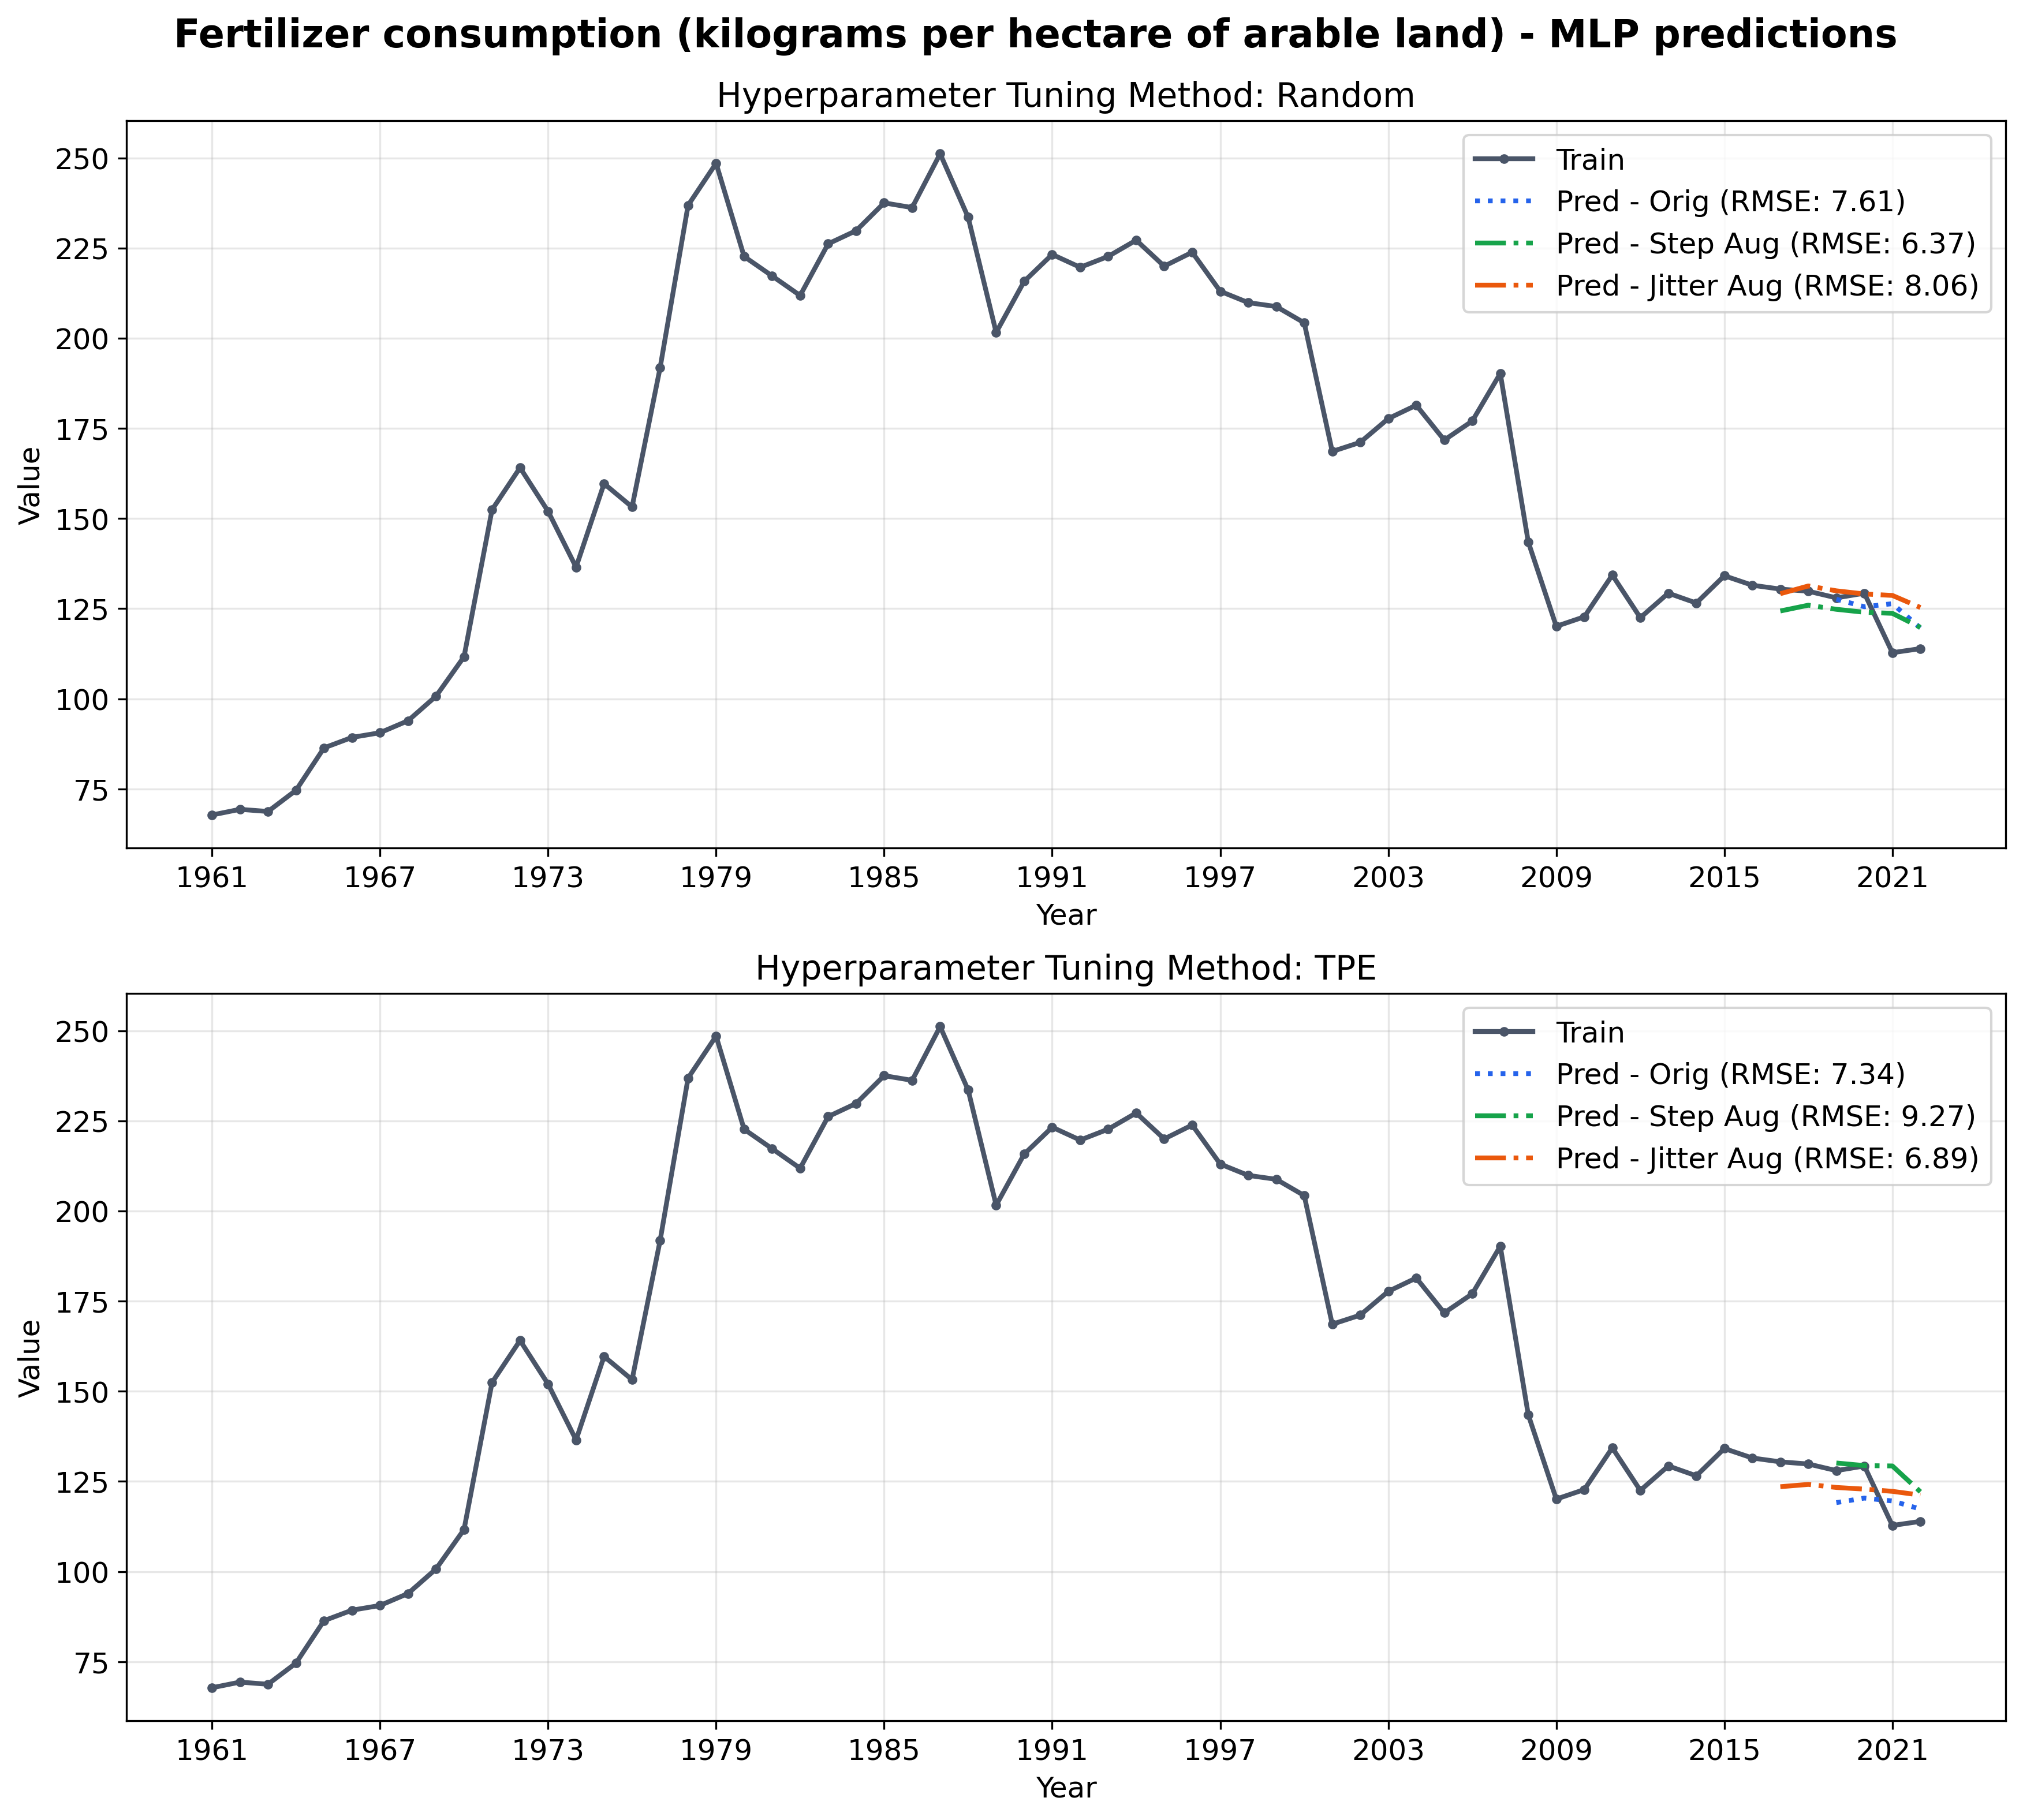

  Random | orig -> years: [2019, 2020, 2021, 2022] preds: [127.62129974365234, 125.53820037841797, 126.38359832763672, 119.66670227050781]
  Random | step_aug -> years: [2017, 2018, 2019, 2020, 2021, 2022] preds: [124.35859680175781, 125.97000122070312, 124.82499694824219, 124.00679779052734, 123.70770263671875, 119.80909729003906]
  Random | jitter_aug -> years: [2017, 2018, 2019, 2020, 2021, 2022] preds: [129.1593017578125, 131.30279541015625, 129.94979858398438, 129.08200073242188, 128.6746063232422, 125.33039855957031]
  TPE | orig -> years: [2019, 2020, 2021, 2022] preds: [119.13169860839844, 120.38909912109375, 119.5886001586914, 117.33999633789062]
  TPE | step_aug -> years: [2019, 2020, 2021, 2022] preds: [130.11500549316406, 129.40139770507812, 129.29510498046875, 122.13980102539062]
  TPE | jitter_aug -> years: [2017, 2018, 2019, 2020, 2021, 2022] preds: [123.54229736328125, 124.18270111083984, 123.33350372314453, 122.87300109863281, 122.25640106201172, 121.22319793701172]


In [31]:
for indicator in INDICATORS:
    if indicator not in orig_aug_subsets:
        print(f"Skipping {indicator}: missing orig_aug_subsets")
        continue

    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing one of orig_train/orig_val/orig_test")
        continue

    if indicator not in predictions_dict:
        print(f"Skipping {indicator}: no predictions available")
        continue

    print(f"\nPlotting predictions for: {indicator}")
    visual.plot_nn_preds(
        indicator,
        predictions_dict,
        train_orig,
        val_orig,
        test_orig,
        model_name="MLP"
    )

    # optional: print a brief summary of stored predictions per sampler/dataset
    for sampler, cats in predictions_dict[indicator].items():
        for cat, res in cats.items():
            yrs = res.get("years")
            vals = res.get("y_pred")
            if yrs is None or vals is None:
                print(f"  {sampler} | {cat}: missing years or preds")
            else:
                print(f"  {sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals,4).tolist()}")

for ogni_indicatore in 28_indicatori:
    # 1. Ottimizza iperparametri specifici per questa serie
    best_params = hyperparameter_tuning(indicatore_data)
    
    # 2. Training del modello con parametri ottimizzati
    model = train_MLP(data, best_params)
    
    # 3. Calcola metriche
    metrics = calculate_all_metrics(test, predictions)
    
    # 4. Salva metriche con iperparametri
    append_metrics_to_excel(indicatore, 'MLP', metrics)


## Future preds - REFITTING ON FULL HISTORY WITH SANITIZED TAIL

In [ ]:
future_predictions_dict1 = {}

for indicator in INDICATORS:
    LAST_DATA_YEAR = int(orig_aug_subsets[indicator]['full_orig']['Year'].iloc[-1])
    TARGET_YEAR = 2030
    future_years = np.arange(LAST_DATA_YEAR + 1, TARGET_YEAR + 1)
    STEPS_AHEAD = len(future_years)

    if indicator not in future_predictions_dict1:
        future_predictions_dict1[indicator] = {}

    print(f"Forecasting for period: {future_years[0]}-{future_years[-1]}")
    for entry in tuning_results:
        if entry['indicator'] != indicator:
            continue

        ind = entry['indicator']
        cat = entry['dataset_type']
        params = entry['best_params']
        sampler = entry['sampler']
        
        if sampler not in future_predictions_dict1[indicator]:
            future_predictions_dict1[indicator][sampler] = {}
        
        print(f"Forecasting {ind} ({sampler}, {cat})")
        train_part = scaled_orig_aug_subsets[ind][f'{cat}_train']
        val_part   = scaled_orig_aug_subsets[ind]['orig_val']
        test_part  = scaled_orig_aug_subsets[ind]['orig_test']
        
        full_values_scaled = np.concatenate([
            train_part['Value'].values,
            val_part['Value'].values,
            test_part['Value'].values
        ])
        
        n_steps = params['n_input_steps']
        X_full, y_full = pipe.create_sequences(full_values_scaled, n_steps)
        
        model = nn.build_mlp_model(params, input_dim=n_steps)
        
        history, model = nn.train_model(
            model, 
            X_train=X_full, 
            y_train=y_full, 
            X_val=X_full,           # self validation : chiedere se ok
            y_val=y_full,
            batch_size=params['batch_size'],
            epochs=150,
            patience=20
        )    
        
        last_window_scaled = full_values_scaled[-n_steps:]
        future_preds_scaled = nn.recursive_forecast(model, last_window_scaled, STEPS_AHEAD)
        
        scaler_y = scalers_subsets[ind]['scaler_y']
        future_preds_real = scaler_y.inverse_transform(future_preds_scaled.reshape(-1, 1)).flatten()
        
        future_predictions_dict1[indicator][sampler][cat] = {
            "years": future_years,
            "y_pred": future_preds_real
        }
        
        # rep.save_future_forecasts(
        #     indicator=ind,
        #     model_type="MLP",
        #     config_name=f"{sampler}_{cat}",
        #     first_future_year=future_years[0],
        #     y_pred=future_preds_real
        # )

Forecasting for period: 2023-2030
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (Random, orig)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (Random, step_aug)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (Random, jitter_aug)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (TPE, orig)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (TPE, step_aug)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (TPE, jitter_aug)



Plotting future forecast for: Fertilizer consumption (kilograms per hectare of arable land)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\MLP_future\MLP_future_fertilizer_abs.png


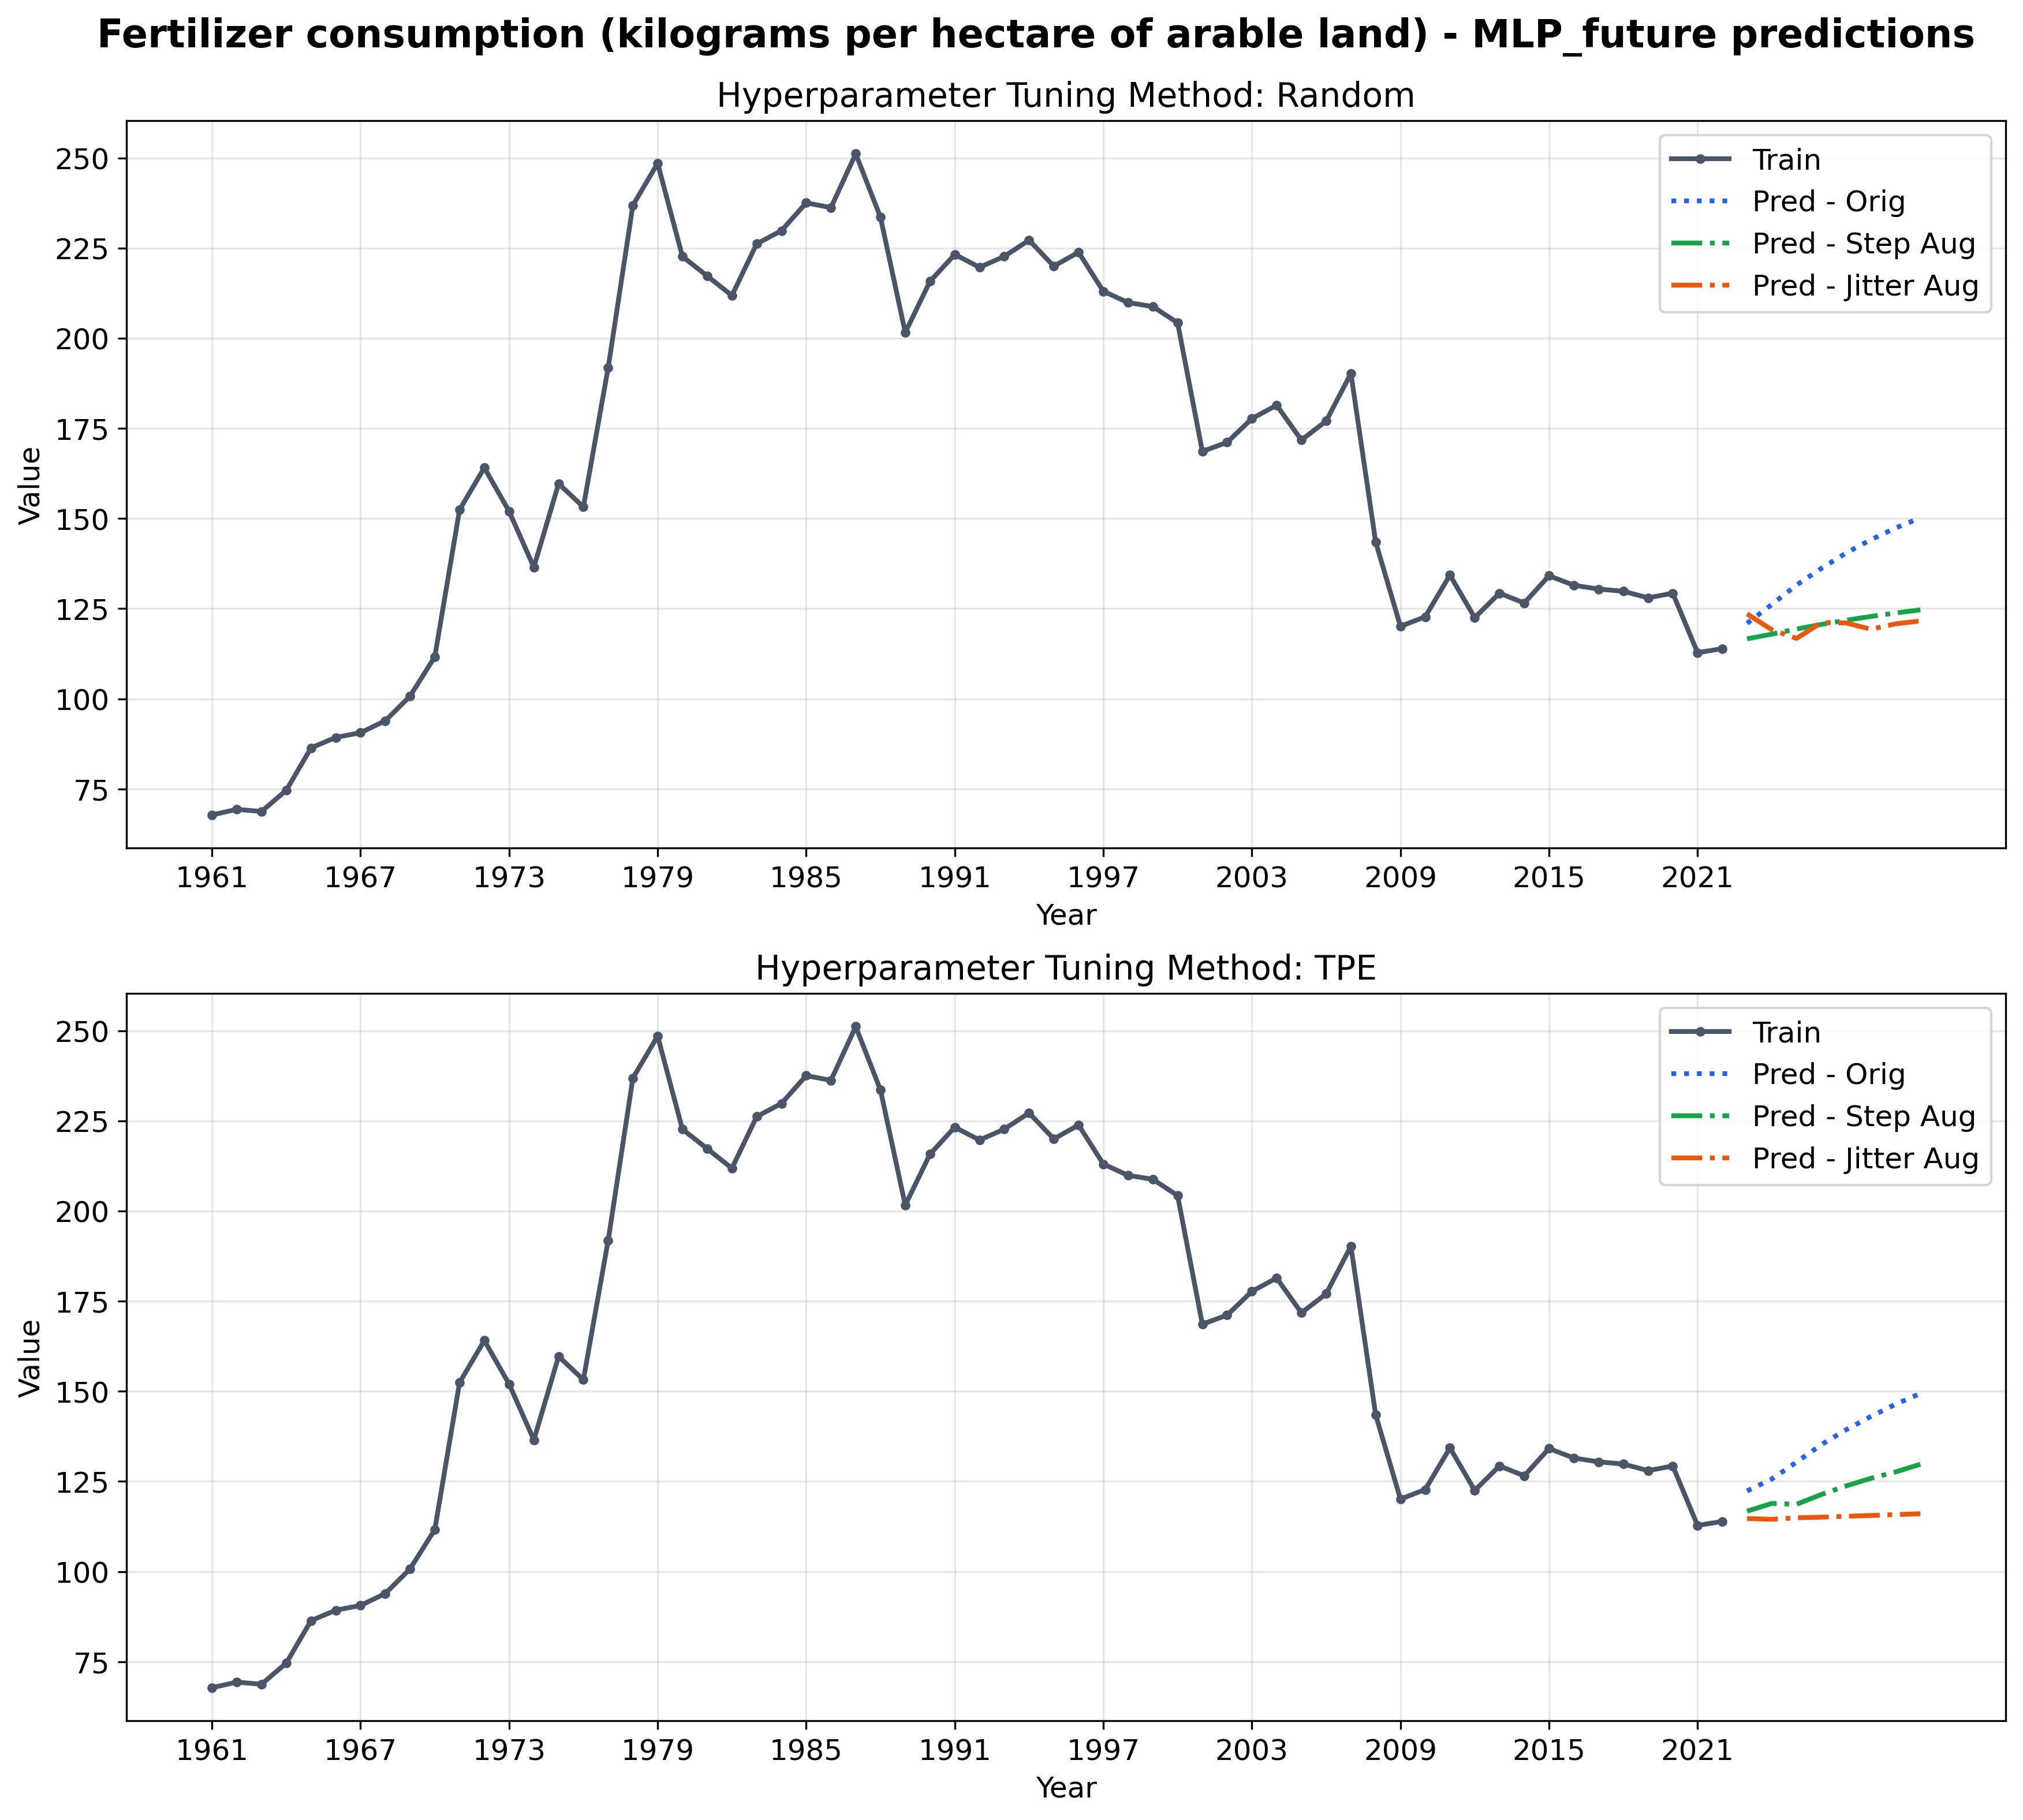

Fertilizer consumption (kilograms per hectare of arable land) | Random | orig -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [120.95110321044922, 126.15630340576172, 131.5625, 136.1811065673828, 140.4333953857422, 144.12710571289062, 147.375, 150.20050048828125]
Fertilizer consumption (kilograms per hectare of arable land) | Random | step_aug -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [116.64800262451172, 117.9352035522461, 119.3634033203125, 120.6312026977539, 121.78669738769531, 122.84230041503906, 123.80400085449219, 124.67980194091797]
Fertilizer consumption (kilograms per hectare of arable land) | Random | jitter_aug -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [123.55960083007812, 119.15440368652344, 116.76329803466797, 121.13600158691406, 121.04810333251953, 119.3010025024414, 120.7958984375, 121.60279846191406]
Fertilizer consumption (kilograms per hectare of arable land) | TPE | orig -> years: [2023, 2024, 2025, 20

In [ ]:
for indicator in future_predictions_dict1:
    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing original subsets")
        continue

    print(f"\nPlotting future forecast for: {indicator}")
    visual.plot_nn_preds(
        indicator,
        future_predictions_dict1,
        train_orig,
        val_orig,
        test_orig,
        model_name="MLP_future"
    )

    # print corresponding future years and predictions for clarity
    for sampler, cats in future_predictions_dict1[indicator].items():
        for cat, pred in cats.items():
            yrs = pred["years"]
            vals = pred["y_pred"]
            print(f"{indicator} | {sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals, 4).tolist()}")

## Future preds - SANITIZED TAIL METHOD

In [42]:
future_predictions_dict2 = {}
N_VAL_YEARS = 5

for indicator in INDICATORS:
    LAST_DATA_YEAR = int(orig_aug_subsets[indicator]['full_orig']['Year'].iloc[-1])
    TARGET_YEAR = 2030
    future_years = np.arange(LAST_DATA_YEAR + 1, TARGET_YEAR + 1)
    STEPS_AHEAD = len(future_years)

    if indicator not in future_predictions_dict2:
        future_predictions_dict2[indicator] = {}

    print(f"Forecasting for period: {future_years[0]}-{future_years[-1]}")
    for entry in tuning_results:
        if entry['indicator'] != indicator:
            continue

        ind = entry['indicator']
        cat = entry['dataset_type']
        params = entry['best_params']
        sampler = entry['sampler']
        
        if sampler not in future_predictions_dict2[indicator]:
            future_predictions_dict2[indicator][sampler] = {}
        
        print(f"Forecasting {ind} ({sampler}, {cat})")
        full_orig = orig_aug_subsets[ind]['full_orig'].sort_values('Year')
        # full_values = full_orig['Value'].values
        
        split_idx = len(full_orig) - N_VAL_YEARS
        orig_train_set = full_orig.iloc[:split_idx]
        orig_val_set = full_orig.iloc[split_idx:]
        
        x_train_vals = orig_train_set['Year']
        y_train_vals = orig_train_set['Value'].values
        
        if cat == 'step_aug':
            step_train_set = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10) 
            final_train_set = step_train_set['Value'].values
        elif cat == 'jitter_aug':
            jitter_train_set = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
            final_train_set = jitter_train_set['Value'].values
        else: # 'orig' -> Nessuna augmentation
            final_train_set = orig_train_set['Value'].values
        
        print(f"  -> Training su {len(final_train_set)} anni (Aumentati) + {len(orig_val_set)} anni (Puri)")
        
        full_values_raw = np.concatenate([final_train_set, orig_val_set['Value'].values])
        
        scaler = MinMaxScaler(feature_range=(0, 1))
        full_values_scaled = scaler.fit_transform(full_values_raw.reshape(-1, 1)).flatten()
        
        n_steps = params['n_input_steps']
        X_full, y_full = pipe.create_sequences(full_values_scaled , n_steps)
        
        model = nn.build_mlp_model(params, input_dim=n_steps)

        
        val_slice_len = len(orig_val_set) + n_steps
        val_set_scaled_slice = full_values_scaled[-val_slice_len:]
        X_val, y_val = pipe.create_sequences(val_set_scaled_slice, n_steps)
    
        # Se la coda è troppo corta per creare sequenze, usiamo X_full (Self-Validation)
        if len(X_val) == 0:
            X_val_final, y_val_final = X_full, y_full
        else:
            X_val_final, y_val_final = X_val, y_val

        history, model = nn.train_model(
            model, 
            X_train=X_full, y_train=y_full, 
            X_val=X_val_final, y_val=y_val_final,
            batch_size=params['batch_size'],
            epochs=150, 
            patience=20
        )
        
        last_window_scaled = full_values_scaled[-n_steps:]
        future_preds_scaled = nn.recursive_forecast(model, last_window_scaled, STEPS_AHEAD)
        
        future_preds_real = scaler.inverse_transform(future_preds_scaled.reshape(-1, 1)).flatten()
        future_predictions_dict2[indicator][sampler][cat] = {
            "years": future_years,
            "y_pred": future_preds_real
        }
        
        # rep.save_future_forecasts(
        #     indicator=ind,
        #     model_type="MLP",
        #     config_name=f"{sampler}_{cat}",
        #     first_future_year=future_years[0],
        #     y_pred=future_preds_real
        # )

Forecasting for period: 2023-2030
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (Random, orig)
  -> Training su 57 anni (Aumentati) + 5 anni (Puri)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (Random, step_aug)
  -> Training su 570 anni (Aumentati) + 5 anni (Puri)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (Random, jitter_aug)
  -> Training su 570 anni (Aumentati) + 5 anni (Puri)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (TPE, orig)
  -> Training su 57 anni (Aumentati) + 5 anni (Puri)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (TPE, step_aug)
  -> Training su 570 anni (Aumentati) + 5 anni (Puri)
Forecasting Fertilizer consumption (kilograms per hectare of arable land) (TPE, jitter_aug)
  -> Training su 570 anni (Aumentati) + 5 anni (Puri)


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.config import PLOTS_DIR, COLORS, SAFE_VAR_NAME, LINE_STYLES

def plot_future_forecasts(variable_name, predictions_dict, train_df, val_df, test_df, model_name):
    save_folder = os.path.join(PLOTS_DIR, str(model_name))
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    full_df = pd.concat([train_df, val_df, test_df]).sort_values('Year')
    years_full = full_df['Year'].values
    values_full = full_df['Value'].values
    
    last_year_hist = years_full[-1]
    last_val_hist = values_full[-1]

    if variable_name not in predictions_dict:
        print(f"Skipping plot for {variable_name}: No predictions found.")
        return
    data = predictions_dict[variable_name]

    fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    
    styles = {
        'orig':       {'color': COLORS['pred_orig'], 'ls': LINE_STYLES['baseline'], 'label': 'Pred - Orig'},
        'step_aug':   {'color': COLORS['pred_step'], 'ls': LINE_STYLES['aug'], 'label': 'Pred - Step Aug'},
        'jitter_aug': {'color': COLORS['pred_jitter'], 'ls': LINE_STYLES['aug'],  'label': 'Pred - Jitter Aug'}
    }
    
    for i, sampler in enumerate(['Random', 'TPE']):
        ax = axes[i]
        sampler_data = data.get(sampler, {})
        
        ax.plot(years_full, values_full, '-', marker='.', color=COLORS['train'], label='Train')

        if sampler_data:
            for ds_type, res in sampler_data.items():
                years_pred = res.get('years', [])
                y_pred = res.get('y_pred', [])
                
                rmse = None
                metrics = res.get('metrics')
                if metrics and isinstance(metrics, dict) and 'RMSE' in metrics:
                    rmse = metrics['RMSE']

                style = styles.get(ds_type, {})
                label_base = style.get('label', ds_type)
                label_txt = f"{label_base} (RMSE: {rmse:.2f})" if rmse is not None else label_base

                plot_years = np.concatenate([[last_year_hist], years_pred])
                plot_values = np.concatenate([[last_val_hist], y_pred])

                ax.plot(plot_years, plot_values, 
                        color=style.get('color', 'red'), 
                        linestyle=style.get('ls', '--'), 
                        linewidth=2, 
                        label=label_txt)
        
        if sampler_data:
            max_year = max([max(v['years']) for v in sampler_data.values()])
            ax.axvspan(last_year_hist, max_year, color='#808080', alpha=0.2)

        ax.set_title(f"Optimization Method: {sampler}", fontsize=14)
        ax.set_xlabel("Year")
        ax.set_ylabel("Value")
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    axes[1].set_xlabel("Year")
    fig.suptitle(f'{variable_name} - Future Forecast (2025-2030)', fontsize=16, fontweight='bold')
    
    safe_var_name = SAFE_VAR_NAME.get(variable_name, variable_name[:10].replace(" ", "_"))
    filename = f"FUTURE_{model_name}_{safe_var_name}.png"
    full_path = os.path.join(save_folder, filename)
    
    plt.tight_layout()
    plt.savefig(full_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Grafico salvato: {full_path}")


Plotting future for: Fertilizer consumption (kilograms per hectare of arable land)


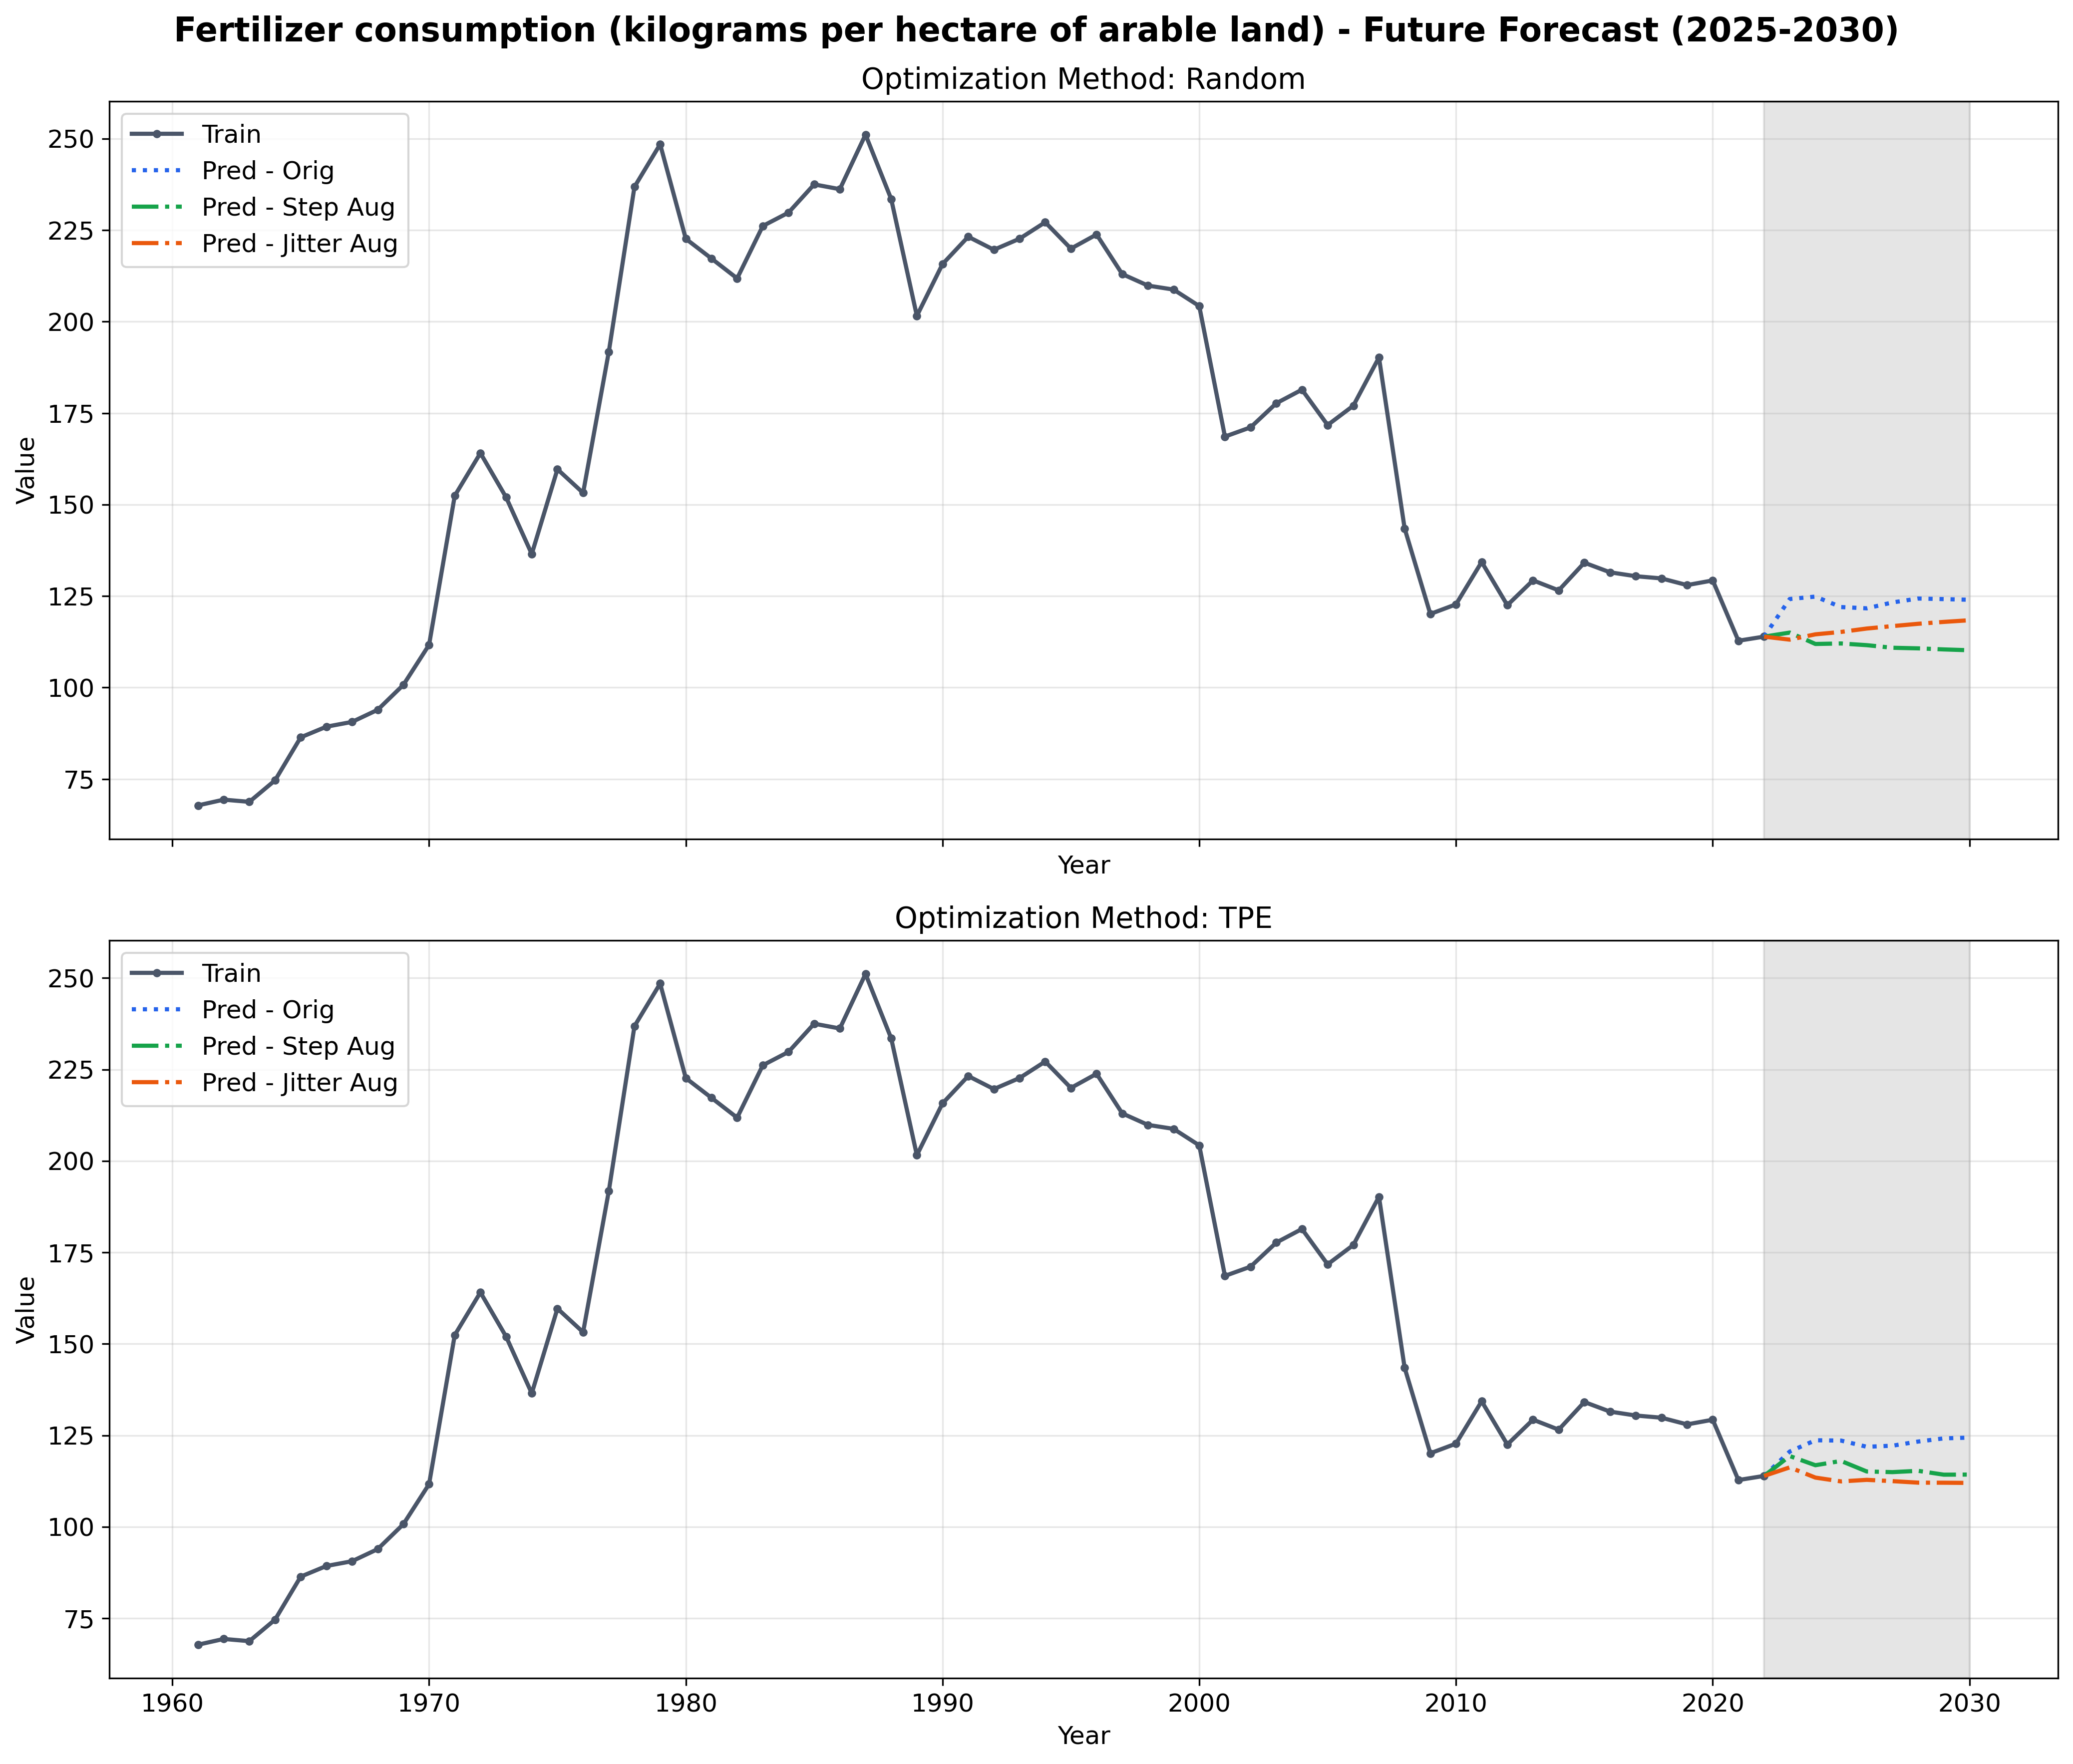

Grafico salvato: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\MLP_Future_2030\FUTURE_MLP_Future_2030_fertilizer_abs.png
Fertilizer consumption (kilograms per hectare of arable land) | Random | orig -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [124.20559692382812, 124.86280059814453, 122.002197265625, 121.65650177001953, 123.26029968261719, 124.33399963378906, 124.17720031738281, 123.99210357666016]
Fertilizer consumption (kilograms per hectare of arable land) | Random | step_aug -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [115.0259017944336, 111.91280364990234, 112.05169677734375, 111.58769989013672, 110.8772964477539, 110.71700286865234, 110.42620086669922, 110.19580078125]
Fertilizer consumption (kilograms per hectare of arable land) | Random | jitter_aug -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [113.0969009399414, 114.54889678955078, 115.20649719238281, 116.13330078125, 116.79560089111328

In [52]:
for indicator in future_predictions_dict2:
    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing subsets")
        continue

    print(f"\nPlotting future for: {indicator}")
    
    plot_future_forecasts(
        variable_name=indicator,
        predictions_dict=future_predictions_dict2,
        train_df=train_orig,
        val_df=val_orig,
        test_df=test_orig,
        model_name="MLP_Future_2030"
    )

    for sampler, cats in future_predictions_dict2[indicator].items():
        for cat, pred in cats.items():
            yrs = pred["years"]
            vals = pred["y_pred"]
            print(f"{indicator} | {sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals, 4).tolist()}")


Plotting future forecast for: Fertilizer consumption (kilograms per hectare of arable land)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\MLP_future\MLP_future_fertilizer_abs.png


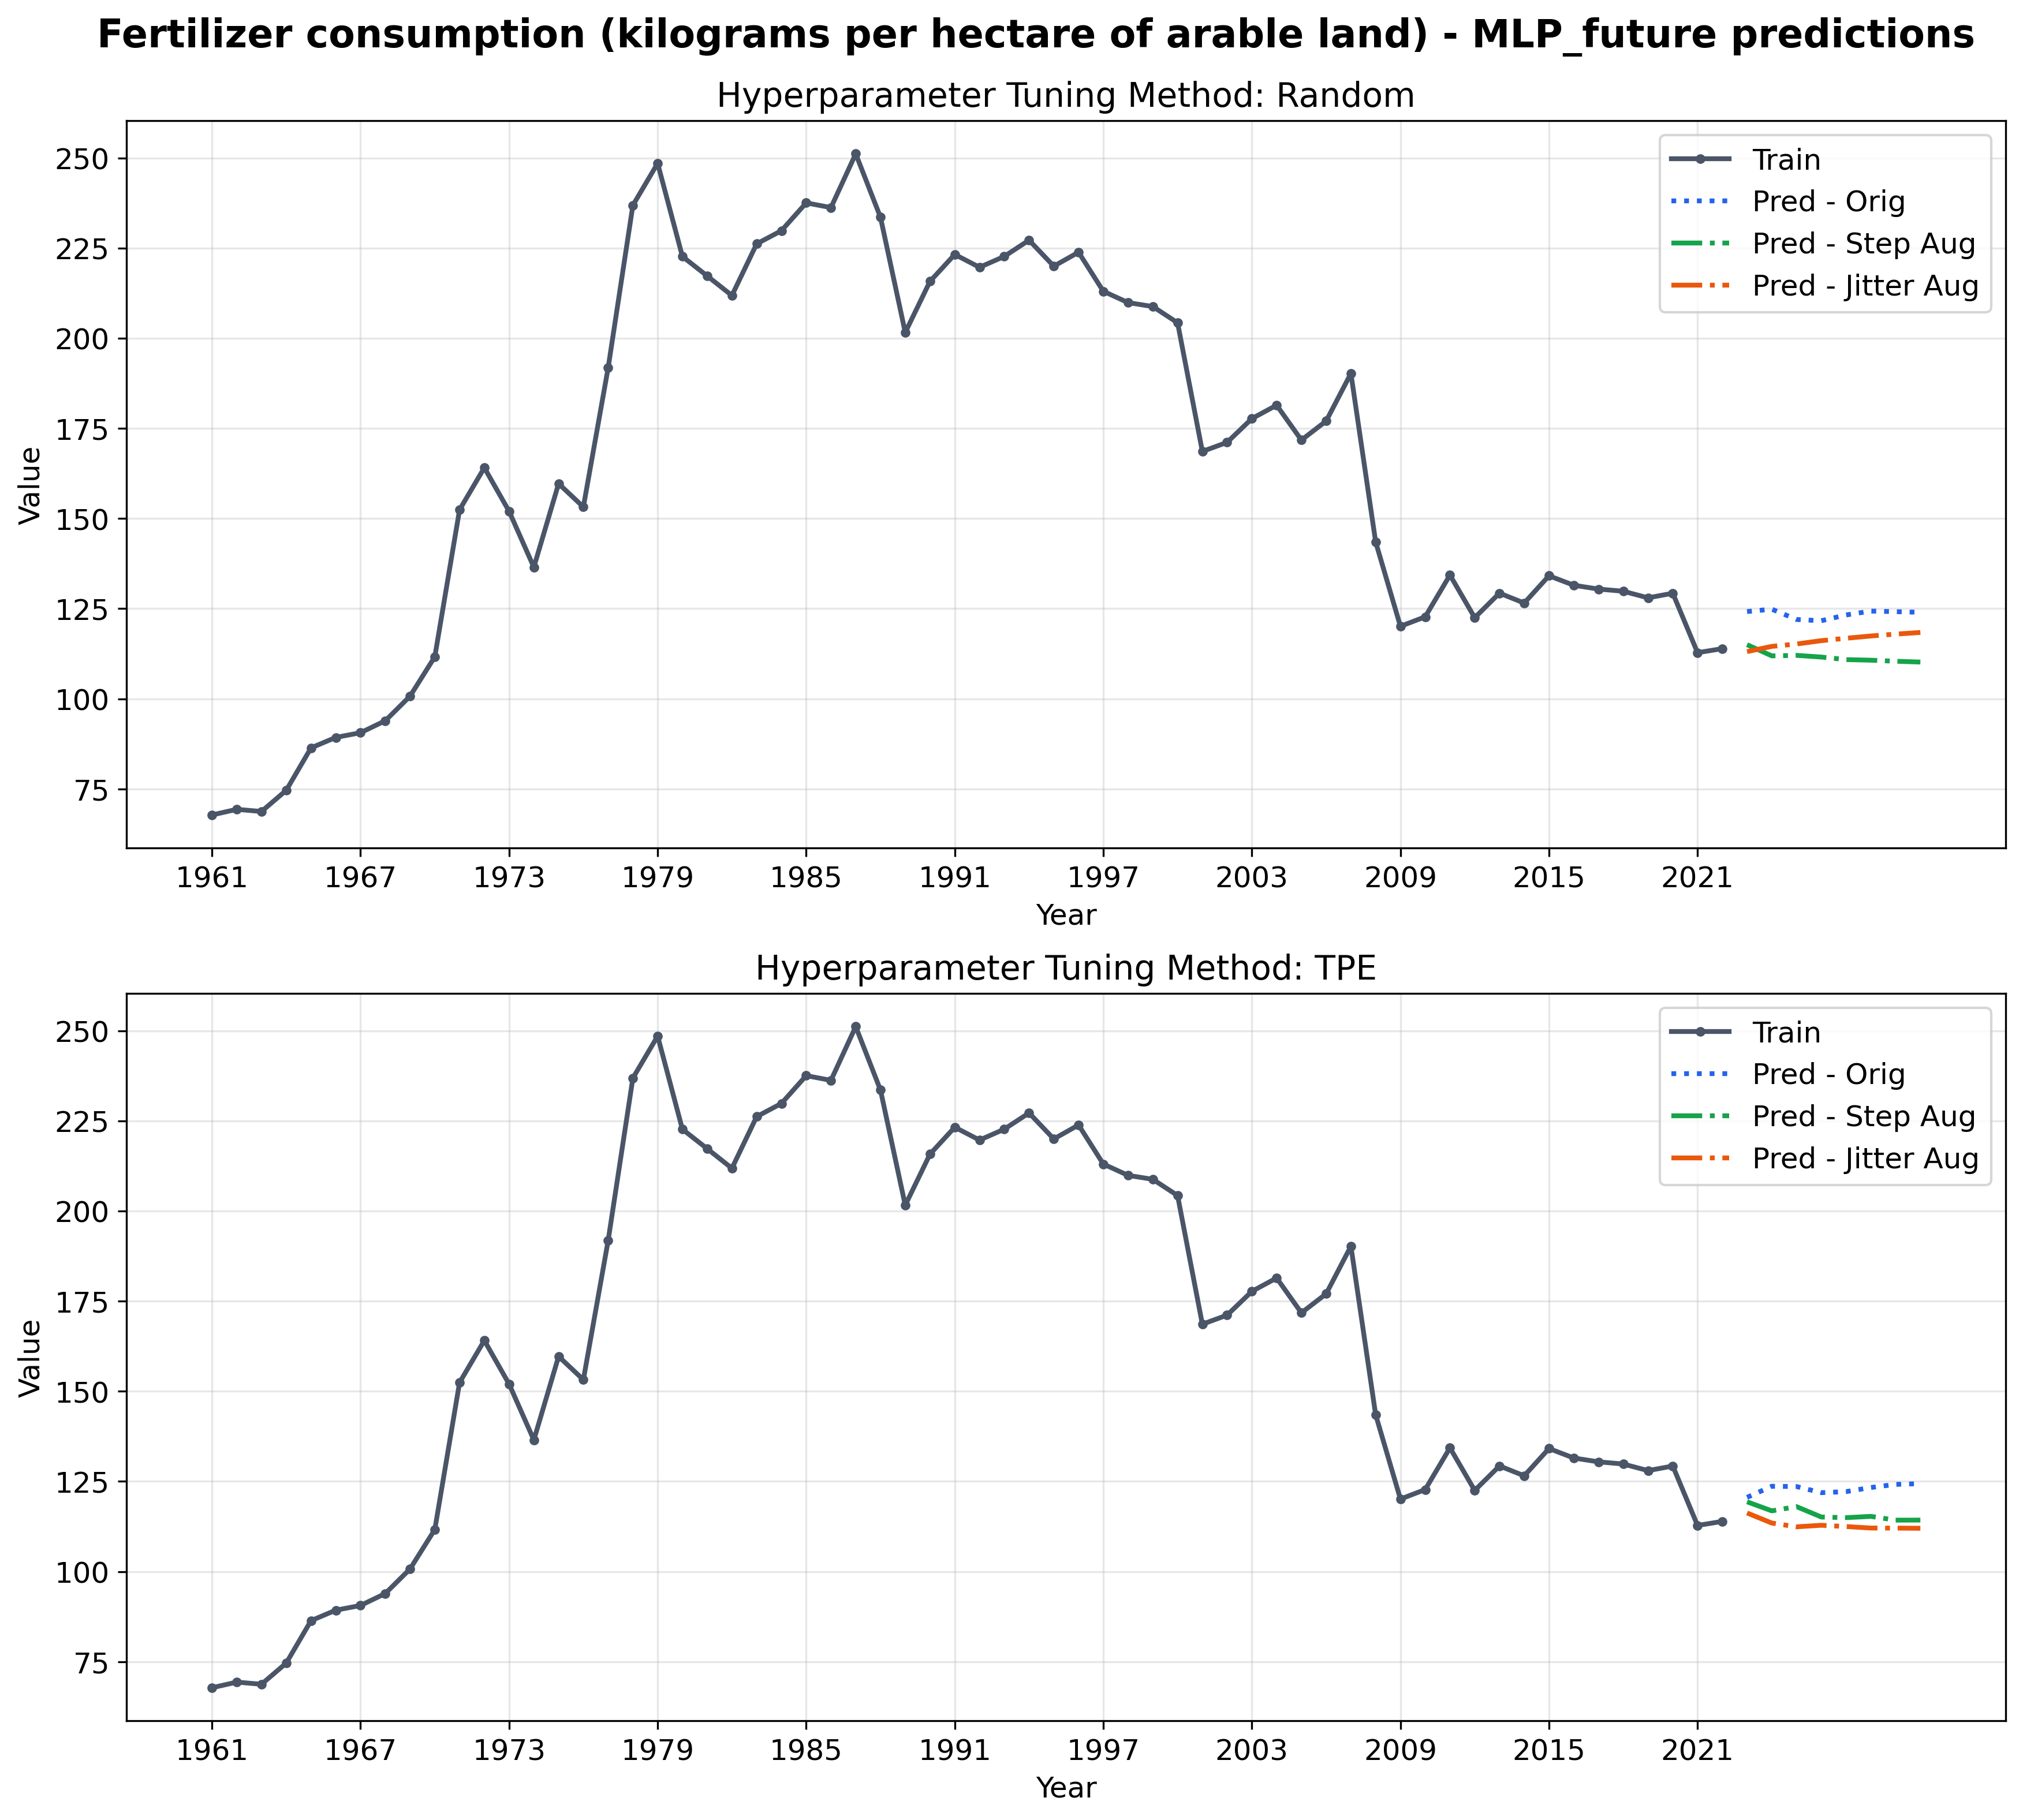

Fertilizer consumption (kilograms per hectare of arable land) | Random | orig -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [124.20559692382812, 124.86280059814453, 122.002197265625, 121.65650177001953, 123.26029968261719, 124.33399963378906, 124.17720031738281, 123.99210357666016]
Fertilizer consumption (kilograms per hectare of arable land) | Random | step_aug -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [115.0259017944336, 111.91280364990234, 112.05169677734375, 111.58769989013672, 110.8772964477539, 110.71700286865234, 110.42620086669922, 110.19580078125]
Fertilizer consumption (kilograms per hectare of arable land) | Random | jitter_aug -> years: [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [113.0969009399414, 114.54889678955078, 115.20649719238281, 116.13330078125, 116.79560089111328, 117.43000030517578, 117.94580078125, 118.39990234375]
Fertilizer consumption (kilograms per hectare of arable land) | TPE | orig -> years: [2023, 

In [47]:
for indicator in future_predictions_dict2:
    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing original subsets")
        continue

    print(f"\nPlotting future forecast for: {indicator}")
    visual.plot_nn_preds(
        indicator,
        future_predictions_dict2,
        train_orig,
        val_orig,
        test_orig,
        model_name="MLP_future"
    )

    # print corresponding future years and predictions for clarity
    for sampler, cats in future_predictions_dict2[indicator].items():
        for cat, pred in cats.items():
            yrs = pred["years"]
            vals = pred["y_pred"]
            print(f"{indicator} | {sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals, 4).tolist()}")